# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.

![](https:///raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)

## Dataset

Download and acces the dataset through its official [PyTorch `FGVCAircraft` class](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) (by setting its constructor argument `annotation_level` to `'variant'`).

##### Imports + dataset

In [1]:
# set up
from dataclasses import dataclass
import torch
import torch.nn.functional as F
from torch.nn import (
    AdaptiveAvgPool2d,
    BatchNorm2d,
    Conv2d,
    Linear,
    MaxPool2d,
    Module,
    ReLU,
    Sequential,
)
from  torchvision.datasets  import FGVCAircraft
from typing import Literal, Optional, Tuple, Union

from pathlib import Path
from PIL import Image
import time
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from torch.optim import Adam

from torchvision.models import ResNet18_Weights, resnet18


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
# the bottom strip of every image is a copyright banner burned in by the
# dataset authors, not part of the photograph
COPYRIGHT_BAR_PX = 20
# FGVC-Aircraft images aren't all the same resolution, so a resize is
# mandatory just to let the DataLoader stack samples into a batch tensor.
STD_SHAPING = T.Compose([T.Resize((256, 256)), T.ToTensor()])


def _read_lines(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]


def _parse_variant_file(data_dir, split):
    classes = _read_lines(data_dir / "variants.txt")
    class_to_idx = {name: idx for idx, name in enumerate(classes)}

    variant_file = data_dir / f"images_variant_{split}.txt"
    samples = []
    for line in _read_lines(variant_file):
        filename, variant = line.split(" ", 1)
        samples.append((filename, class_to_idx[variant]))
    return samples


class FGVCAircraftDataset(Dataset):
    """FGVC-Aircraft dataset, labeled by variant.

    Each `images_variant_{split}.txt` file already lists exactly the images
    belonging to that split together with their variant label, so it alone
    is enough to recover both the train/val/test membership and the class
    of every image (no need to cross-reference `images_{split}.txt`).
    """

    def __init__(self, root, split="train", transform=None):
        self.transform = (
            STD_SHAPING if transform is None else T.Compose([STD_SHAPING, transform])
        )
        data_dir = Path(root) / "data"

        self.images_dir = data_dir / "images"
        self.samples = _parse_variant_file(data_dir, split)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        filename, label = self.samples[index]
        image_path = self.images_dir / f"{filename}.jpg"

        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        image = image.crop((0, 0, width, height - COPYRIGHT_BAR_PX))

        if self.transform is not None:
            image = self.transform(image)

        return image, label



## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

##### Network modules: stem layers downsampling -> CNN feature extractor (inception or resnet) -> FC classifier

In [3]:
def _as_hw(size):
    """Helper to map a side length L into the shape tuple (L, L)"""
    return (size, size) if isinstance(size, int) else tuple(size)


class Stem(Module):
    """Resizes the input to a canonical size, then downsamples with
    `conv -> batchnorm -> activation -> maxpool` blocks.

    With the default `canonical_size=256` and three stride-2 poolings,
    output is 256 / 2**3 = 32 pixels per side, at `channels[-1]` channels.
    """

    def __init__(self, in_channels=3, canonical_size=256, channels=(32, 64, 128), kernel_size=3):
        super().__init__()
        self.canonical_size = _as_hw(canonical_size)

        kernel_padding = kernel_size // 2
        blocks = []
        prev_channels = in_channels
        for out_channels in channels:
            blocks += [
                Conv2d(prev_channels, out_channels, kernel_size, padding=kernel_padding),
                BatchNorm2d(out_channels),
                ReLU(inplace=True),
                MaxPool2d(2),
            ]
            prev_channels = out_channels
        self.blocks = Sequential(*blocks)

    def forward(self, x):
        x = F.interpolate(x, size=self.canonical_size, mode="bilinear", align_corners=False)
        return self.blocks(x)


class ResidualStage(Module):
    """conv(stride) -> bn -> act -> conv(stride=1) -> bn, added to a 1x1-conv
    shortcut that reshapes the input to the output's shape, then activated."""

    def __init__(self, in_channels, out_channels, stride=2, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = BatchNorm2d(out_channels)
        self.conv2 = Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = BatchNorm2d(out_channels)
        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.activation(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        return self.activation(out + identity)


def _split_channels(total, parts):
    base, remainder = divmod(total, parts)
    return [base + (1 if i < remainder else 0) for i in range(parts)]


class InceptionStage(Module):
    """Four parallel paths (pool, 1x1, 3x3, 5x5) whose outputs are
    concatenated to out_channels, added to a 1x1-conv shortcut that reshapes
    the input to the output's shape, then activated — same contract as
    `ResidualStage`.

    The 3x3 and 5x5 paths are preceded by a 1x1 "reduce" convolution that
    bottlenecks the channel count before the spatially expensive convolution,
    as in GoogLeNet.
    """

    def __init__(self, in_channels, out_channels, stride=2, branch_channels=None, reduce_channels=None):
        super().__init__()

        pool_channels, conv1_channels, conv3_channels, conv5_channels = branch_channels or _split_channels(out_channels, 4)
        if reduce_channels is None:
            reduce_channels = max(out_channels // 4, 1)

        self.pool_branch = Sequential(
            MaxPool2d(kernel_size=3, stride=stride, padding=1),
            Conv2d(in_channels, pool_channels, kernel_size=1),
            BatchNorm2d(pool_channels),
            ReLU(inplace=True),
        )
        self.conv1_branch = Sequential(
            Conv2d(in_channels, conv1_channels, kernel_size=1, stride=stride),
            BatchNorm2d(conv1_channels),
            ReLU(inplace=True),
        )
        self.conv3_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(reduce_channels, conv3_channels, kernel_size=3, stride=stride, padding=1),
            BatchNorm2d(conv3_channels),
            ReLU(inplace=True),
        )
        self.conv5_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(reduce_channels, conv5_channels, kernel_size=5, stride=stride, padding=2),
            BatchNorm2d(conv5_channels),
            ReLU(inplace=True),
        )

        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)
        branches = [self.pool_branch(x), self.conv1_branch(x), self.conv3_branch(x), self.conv5_branch(x)]
        out = torch.cat(branches, dim=1)
        return self.activation(out + identity)


class FeatureExtractor(Module):
    """Stack of stages (`ResidualStage` by default), each halving feature
    map size while increasing channels. Agnostic to which stage type is
    used, as long as it follows the `(in_channels, out_channels, stride)`
    contract shared by `ResidualStage` and `InceptionStage`.

    With the defaults, an `in_channels=128` input at 32x32 (the Stem's
    default output) becomes 512 channels at 8x8 (32 / 2**2).
    """

    def __init__(self, in_channels=128, stage_channels=(256, 512), stride=2, stage_cls=ResidualStage, stage_kwargs=None):
        super().__init__()
        stage_kwargs = stage_kwargs or {}

        stages = []
        prev_channels = in_channels
        for out_channels in stage_channels:
            stages.append(stage_cls(prev_channels, out_channels, stride=stride, **stage_kwargs))
            prev_channels = out_channels
        self.stages = Sequential(*stages)

    def forward(self, x):
        return self.stages(x)


class Classifier(Module):
    """Global average pooling into an MLP head. Returns raw logits: pair
    with `nn.CrossEntropyLoss`, which applies log-softmax internally."""

    def __init__(self, in_channels=512, hidden_dim=256, num_classes=100):
        super().__init__()
        self.pool = AdaptiveAvgPool2d(output_size=1)
        self.fc1 = Linear(in_channels, hidden_dim)
        self.activation = ReLU(inplace=True)
        self.fc2 = Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.pool(x).flatten(1)
        x = self.activation(self.fc1(x))
        return self.fc2(x)


##### Network definition with architecture parameters dataclass

In [4]:
@dataclass
class CnnConfig:
    """Hyperparameters for `Cnn`. Defaults reproduce the module's original,
    hardcoded defaults, with a `ResidualStage`-based feature extractor."""

    in_channels: int = 3
    num_classes: int = 100

    # Stem
    canonical_size: Union[int, Tuple[int, int]] = 256
    stem_channels: Tuple[int, ...] = (32, 64, 128)
    stem_kernel_size: int = 3

    # Feature extractor
    stage_channels: Tuple[int, ...] = (256, 512)
    stage_stride: int = 2
    block_type: Literal["resnet", "inception"] = "resnet"
    resnet_kernel_size: int = 3
    inception_branch_channels: Optional[Tuple[int, int, int, int]] = None
    inception_reduce_channels: Optional[int] = None

    # Classifier
    classifier_hidden_dim: int = 256


class Cnn(Module):
    def __init__(self, config=None):
        super().__init__()
        config = config or CnnConfig()

        self.stem = Stem(
            in_channels=config.in_channels,
            canonical_size=config.canonical_size,
            channels=config.stem_channels,
            kernel_size=config.stem_kernel_size,
        )

        if config.block_type == "resnet":
            stage_cls = ResidualStage
            stage_kwargs = {"kernel_size": config.resnet_kernel_size}
        elif config.block_type == "inception":
            stage_cls = InceptionStage
            stage_kwargs = {
                "branch_channels": config.inception_branch_channels,
                "reduce_channels": config.inception_reduce_channels,
            }
        else:
            raise ValueError(f"Unknown block_type: {config.block_type!r}")

        self.feature_extractor = FeatureExtractor(
            in_channels=config.stem_channels[-1],
            stage_channels=config.stage_channels,
            stride=config.stage_stride,
            stage_cls=stage_cls,
            stage_kwargs=stage_kwargs,
        )

        self.classifier = Classifier(
            in_channels=config.stage_channels[-1],
            hidden_dim=config.classifier_hidden_dim,
            num_classes=config.num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.feature_extractor(x)
        return self.classifier(x)


##### Training code

In [5]:
def _run_epoch(model, loader, criterion, optimizer=None, device="cuda"):
    model.to(device)
    model.train(optimizer is not None)

    total_loss = 0.0
    correct = 0
    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()

    dataset_size = len(loader.dataset)
    return total_loss / dataset_size, correct / dataset_size


def evaluate(model, root, transform=None, batch_size=64, device="cuda"):
    """Computes loss and accuracy on the test split"""

    loader = DataLoader(
        FGVCAircraftDataset(root, split="test", transform=transform),
        batch_size=batch_size,
        shuffle=False,
    )
    criterion = nn.CrossEntropyLoss()
    return _run_epoch(model, loader, criterion, device=device)


def test_performance_callback(n: int, valset):
    """Callback to benchmark the test performance each `n` epochs"""
    history = {"loss": [], "accuracy": []}

    def callback(epoch, model, train_loss, train_accuracy):
        criterion = nn.CrossEntropyLoss()
        loader = DataLoader(
            valset,
            batch_size=64,
            shuffle=False,
        )
        if epoch % n == 0:
            loss, accuracy = _run_epoch(model, loader, criterion, device=DEVICE)
            history["loss"].append(loss)
            history["accuracy"].append(accuracy)

    return history, callback


def train(
    model,
    loader,
    device="cuda",
    callback=None,
    epochs=1,
    learning_rate=1e-3,
    optimizer=None,
    scheduler=None,
):
    """Trains on the merged train+val split (`trainval`) for `epochs` epochs"""

    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = Adam(model.parameters(), lr=learning_rate)

    epoch_durations = []
    losses = []
    accuracies = []

    for epoch in range(epochs):
        start = time.perf_counter()
        loss, accuracy = _run_epoch(
            model, loader, criterion, optimizer=optimizer, device=device
        )
        duration = time.perf_counter() - start
        epoch_durations.append(duration)
        losses.append(loss)
        accuracies.append(accuracy)

        if scheduler is not None:
            scheduler.step()
        if callback is not None:
            callback(epoch, model, loss, accuracy)

        avg_duration = sum(epoch_durations) / len(epoch_durations)
        eta = avg_duration * (epochs - epoch - 1)
        print(
            f"epoch {epoch + 1}/{epochs} loss={loss:.4f} accuracy={accuracy:.4f} "
            f"time={duration:.1f}s eta={eta / 60:.1f}min"
        )

    return model, losses, accuracies


##### CNN training

In [6]:
BATCH_SIZE = 128
CANONICAL_SIZE = (256,256)
TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])


trainset = FGVCAircraft(
    root='./data',
    split = 'train',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)

In [7]:
configs = [
    ("base", CnnConfig(
        stem_channels=(16, 32, 64),
        stage_channels=(128, 256),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=256,
    )),
    # ("other", CnnConfig(
    #     stem_channels=(48, 48, 48),
    #     stage_channels=(96, 192, 384),
    #     canonical_size=CANONICAL_SIZE,
    #     block_type="inception",
    #     classifier_hidden_dim=384,
    # )),
]

results = {}

for name, c in configs:
    loader = DataLoader(
        dataset=trainset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    history, callback = test_performance_callback(1, valset)
    model, losses, accuracies = train(Cnn(c), loader, epochs=20, learning_rate=0.001, device=DEVICE, callback=callback)
    results[name] = {
        "train_loss": losses,
        "train_accuracy": accuracies,
        "val_losses": history["loss"],
        "val_accuracy": history["accuracy"],
    }

epoch 1/20 loss=4.5865 accuracy=0.0204 time=38.9s eta=12.3min
epoch 2/20 loss=4.4667 accuracy=0.0294 time=38.1s eta=11.6min
epoch 3/20 loss=4.3779 accuracy=0.0360 time=38.8s eta=10.9min
epoch 4/20 loss=4.2541 accuracy=0.0465 time=38.8s eta=10.3min
epoch 5/20 loss=4.1364 accuracy=0.0567 time=38.8s eta=9.7min
epoch 6/20 loss=4.0040 accuracy=0.0708 time=38.3s eta=9.0min
epoch 7/20 loss=3.8829 accuracy=0.0819 time=38.0s eta=8.3min
epoch 8/20 loss=3.7364 accuracy=0.0978 time=38.1s eta=7.7min
epoch 9/20 loss=3.6318 accuracy=0.1080 time=38.4s eta=7.1min
epoch 10/20 loss=3.5097 accuracy=0.1263 time=38.2s eta=6.4min
epoch 11/20 loss=3.3967 accuracy=0.1404 time=38.6s eta=5.8min
epoch 12/20 loss=3.3173 accuracy=0.1383 time=38.1s eta=5.1min
epoch 13/20 loss=3.2598 accuracy=0.1578 time=37.9s eta=4.5min
epoch 14/20 loss=3.0653 accuracy=0.1917 time=38.3s eta=3.8min
epoch 15/20 loss=2.9665 accuracy=0.2040 time=38.1s eta=3.2min
epoch 16/20 loss=2.8836 accuracy=0.2121 time=38.0s eta=2.6min
epoch 17/20 l

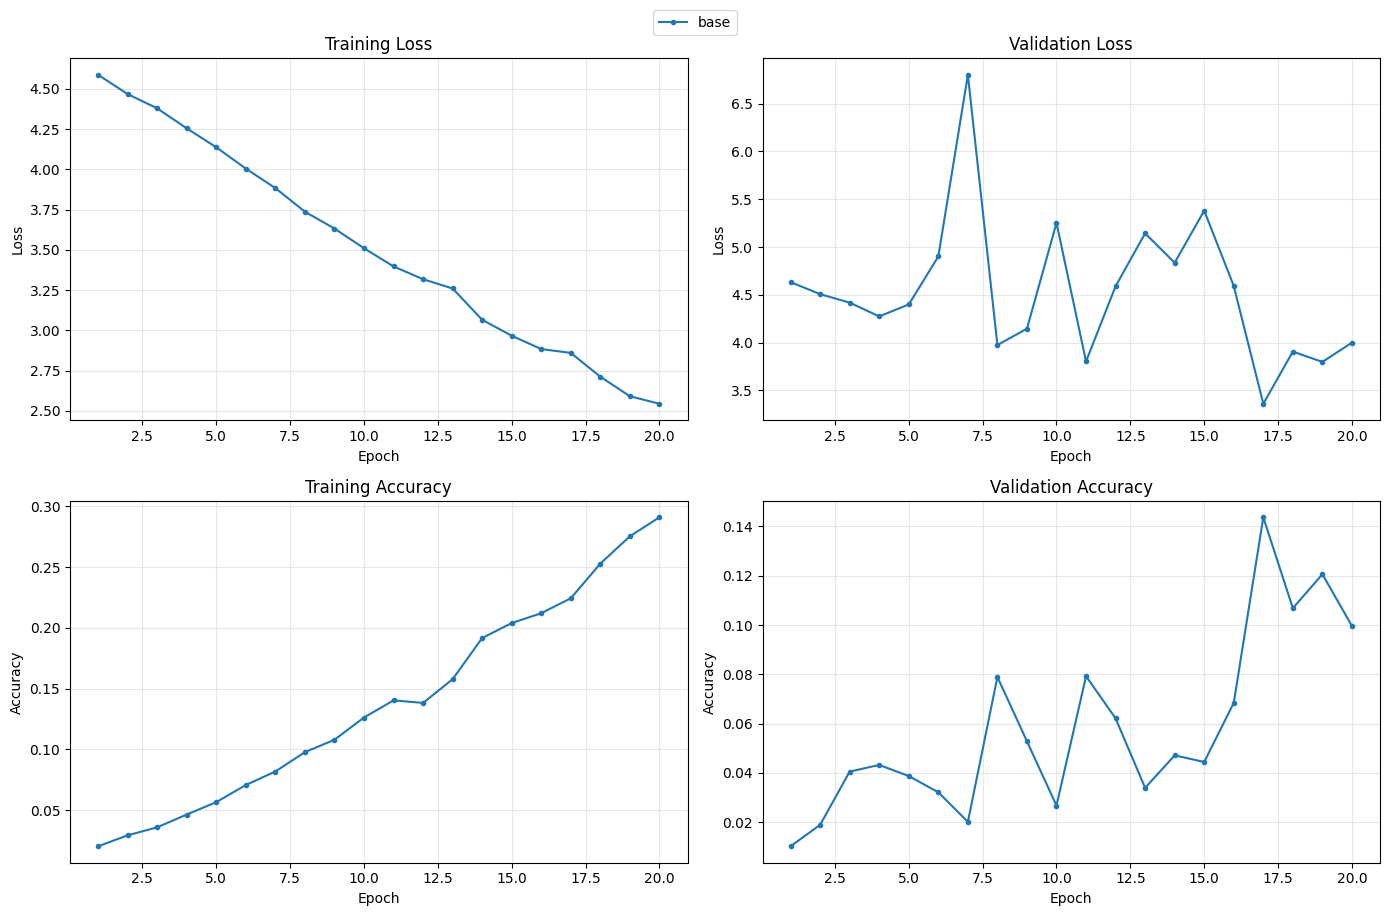

In [8]:
import matplotlib.pyplot as plt

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

In [ ]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = CnnConfig(
    stem_channels=(16, 32, 64),
    stage_channels=(128, 256),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
)

ds = FGVCAircraftDataset("data/fgvc-aircraft", split="trainval", transform=TRANSFORM)
print(f"Loaded {len(ds)} images")
loader = DataLoader(
    dataset=ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
history, callback = test_performance_callback(5)

model, _, _ = train(Cnn(CONFIG), loader, epochs=20, learning_rate=0.001, device=DEVICE, callback=callback)
loss, accuracy = evaluate(
    model,
    "data/fgvc-aircraft",
    transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history)


Loaded 6667 images
epoch 1/20 loss=4.5378 accuracy=0.0171 time=148.4s eta=47.0min
epoch 2/20 loss=4.2752 accuracy=0.0463 time=144.9s eta=44.0min
epoch 3/20 loss=3.8936 accuracy=0.0742 time=146.8s eta=41.6min
epoch 4/20 loss=3.5800 accuracy=0.1069 time=189.8s eta=42.0min
epoch 5/20 loss=3.3778 accuracy=0.1297 time=171.1s eta=40.1min
epoch 6/20 loss=3.2167 accuracy=0.1455 time=151.6s eta=37.1min
epoch 7/20 loss=3.0641 accuracy=0.1729 time=151.2s eta=34.2min
epoch 8/20 loss=2.9399 accuracy=0.1918 time=157.3s eta=31.5min
epoch 9/20 loss=2.7780 accuracy=0.2271 time=156.3s eta=28.9min
epoch 10/20 loss=2.6538 accuracy=0.2479 time=150.0s eta=26.1min
epoch 11/20 loss=2.5250 accuracy=0.2670 time=151.5s eta=23.4min
epoch 12/20 loss=2.3824 accuracy=0.3045 time=153.4s eta=20.8min
epoch 13/20 loss=2.3032 accuracy=0.3261 time=157.5s eta=18.2min
epoch 14/20 loss=2.1311 accuracy=0.3622 time=161.1s eta=15.7min
epoch 15/20 loss=1.9929 accuracy=0.3922 time=150.1s eta=13.0min
epoch 16/20 loss=1.9176 accura

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

In [ ]:
NUM_CLASSES = 100


def build_resnet():
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model

In [ ]:
# TODO: to be filled with hyperparameters from the first experiment once its done
learning_rate = ...
epochs = ...
optimizer = ...
scheduler = ...

resnet = build_resnet()
model, losses, accuracies = train(
    model,
    loader,
    device=DEVICE,
    # training hyperparameters to tweak
    epochs=epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    learning_rate=learning_rate
)

In [ ]:
# TODO: tuning of the hyperparameters, given the baseline at the previous step

resnet = build_resnet()
model, losses, accuracies = train(
    model,
    loader,
    device=DEVICE,
    # training hyperparameters to tweak
    epochs=epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    learning_rate=learning_rate
)